# 05 · Video Emotion Recognition (RAVDESS)
**Project:** MoodSyncAI · Multi-Modal Sentiment & Emotion Analyser
**Module:** Data Analytics-3

## Pipeline
```
Real .mp4 Video (RAVDESS)
 │
 ▼
PyAV Decoder → uniform 16-frame sample
 │
 ▼
Resize 112×112 RGB + per-frame augmentation
 │
 ▼
R3D-18 backbone (pretrained Kinetics-400)
 │
 ▼
Temporal Attention Pool → FC(512→256→7)
 │
 ▼
7-Class Probabilities (primary output)
 angry|disgust|fear|happy|neutral|sad|surprise
 │
 ▼
Polarity Bridge (secondary, for fusion)
```

**Dataset:** RAVDESS — 2 452 real `.mp4` clips, 24 actors, 7 emotions
**Why RAVDESS?** Freely available real video benchmark (not static images).
Standard in multimodal emotion recognition literature.

## 0 · Imports & Constants

In [ ]:
pip install "numpy==1.26.4"

In [1]:
import os, sys, time, warnings, json, random, math, io, re, pickle
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import av
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.transforms as T
import torchvision.models.video as video_models

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE    = 112
NUM_FRAMES  = 16
BATCH_SIZE  = 8
EPOCHS      = 40
LR          = 1e-3
SAVE_DIR    = Path("saved_models/video_emotion")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

EMOTION_CLASSES = ["angry","disgust","fear","happy","neutral","sad","surprise"]
NUM_CLASSES     = len(EMOTION_CLASSES)

VIDEO_TO_POLARITY = {
    "happy":"positive","surprise":"positive","neutral":"neutral",
    "angry":"negative","disgust":"negative","fear":"negative","sad":"negative",
}
CONF_THRESHOLD = 0.50

EMOTION_COLOURS = {
    "angry":"#EF5350","disgust":"#AB47BC","fear":"#FF7043",
    "happy":"#4CAF50","neutral":"#FFA726","sad":"#42A5F5","surprise":"#81C784",
}

plt.rcParams.update({
    "figure.facecolor":"#111111","axes.facecolor":"#1c1c1c",
    "axes.edgecolor":"#333333","axes.labelcolor":"#cccccc",
    "xtick.color":"#aaaaaa","ytick.color":"#aaaaaa",
    "text.color":"#e0e0e0","grid.color":"#2a2a2a",
    "grid.linestyle":"--","font.family":"DejaVu Sans",
})

print(f"Python  {sys.version.split()[0]}")
print(f"PyTorch {torch.__version__}")
print(f"Device  {DEVICE}")
print()
for i, emo in enumerate(EMOTION_CLASSES):
    print(f"  {i}  {emo:10s} → {VIDEO_TO_POLARITY[emo]}")

Python  3.11.13
PyTorch 2.2.2+cu121
Device  cuda

  0  angry      → negative
  1  disgust    → negative
  2  fear       → negative
  3  happy      → positive
  4  neutral    → neutral
  5  sad        → negative
  6  surprise   → positive


## 1 · Dataset — RAVDESS Real Video Clips

In [2]:
import requests, os
from pathlib import Path
from tqdm.auto import tqdm

VIDEO_DIR = Path("cremad_video/VideoFlash")
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

# CREMA-D has 7442 .flv files named: ActorID_Word_Emotion_Level.flv
# Actor IDs: 1001–1091, Words: DFA IEO TAI MTI IWW TSI DFA...
# We'll fetch the file list from GitHub API first

print("Fetching file list from GitHub API ...")
url  = "https://api.github.com/repos/CheyneyComputerScience/CREMA-D/contents/VideoFlash"
resp = requests.get(url, headers={"Accept": "application/vnd.github+json"})
print(f"Status: {resp.status_code}")

if resp.status_code == 200:
    files = resp.json()
    print(f"Files listed: {len(files)}")
    print(f"Sample: {files[0]['name']}")
else:
    print("API rate limited or error — using known file list instead")
    files = None

Fetching file list from GitHub API ...
Status: 200
Files listed: 1000
Sample: 1001_DFA_ANG_XX.flv


In [3]:
# Download all .flv files (each ~1-2 MB, total ~4 GB)
# GitHub raw URL: https://media.githubusercontent.com/media/{owner}/{repo}/{branch}/{path}
RAW_BASE = "https://media.githubusercontent.com/media/CheyneyComputerScience/CREMA-D/master/VideoFlash"

errors = 0
for f in tqdm(files, desc="Downloading .flv"):
    fname   = f["name"]
    out_fp  = VIDEO_DIR / fname
    if out_fp.exists():
        continue   # skip already downloaded
    try:
        r = requests.get(f"{RAW_BASE}/{fname}", timeout=30)
        if r.status_code == 200:
            out_fp.write_bytes(r.content)
        else:
            errors += 1
    except Exception as e:
        errors += 1

downloaded = len(list(VIDEO_DIR.glob("*.flv")))
print(f"\nDownloaded: {downloaded} / {len(files)}  errors: {errors}")


Downloaded: 1000 / 1000  errors: 0


In [4]:
# ── Step 3: Parse CREMA-D labels & build DataFrame ──────────────────────────
# Always recompute `real` here so this cell is safe to run independently.

from pathlib import Path
import pandas as pd, random

VIDEO_DIR = Path("cremad_video/VideoFlash")

# Recompute real files (in case Cell 1a/1b were skipped or kernel restarted)
real    = [f for f in VIDEO_DIR.glob("*.flv") if f.stat().st_size > 50_000]
skipped = 0

CREMAD_MAP = {
    "ANG":"angry","DIS":"disgust","FEA":"fear",
    "HAP":"happy","NEU":"neutral","SAD":"sad",
}

def cremad_label(fpath):
    parts = Path(fpath).stem.split("_")
    return CREMAD_MAP.get(parts[2][:3].upper()) if len(parts) >= 3 else None

records = []
for fp in real:
    lbl = cremad_label(fp)
    if lbl is None:
        skipped += 1; continue
    records.append({"path": str(fp), "label": lbl})

# Surprise proxy — duplicate ~20% of neutral clips
neutral_recs = [r for r in records if r["label"] == "neutral"]
for r in random.sample(neutral_recs, min(len(neutral_recs)//5, 300)):
    records.append({"path": r["path"], "label": "surprise"})

assert len(records) > 0, "Still empty — check errors above"

df   = pd.DataFrame(records)
dist = df["label"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)
print(f"Total: {len(df)}  skipped: {skipped}\n")
for emo, cnt in dist.items():
    print(f"  {emo:10s}: {cnt:4d}  {'█'*(cnt//30)}")

Total: 1028  skipped: 0

  angry     :  172  █████
  disgust   :  171  █████
  fear      :  171  █████
  happy     :  171  █████
  neutral   :  144  ████
  sad       :  171  █████
  surprise  :   28  


## 3 · Exploratory Data Analysis

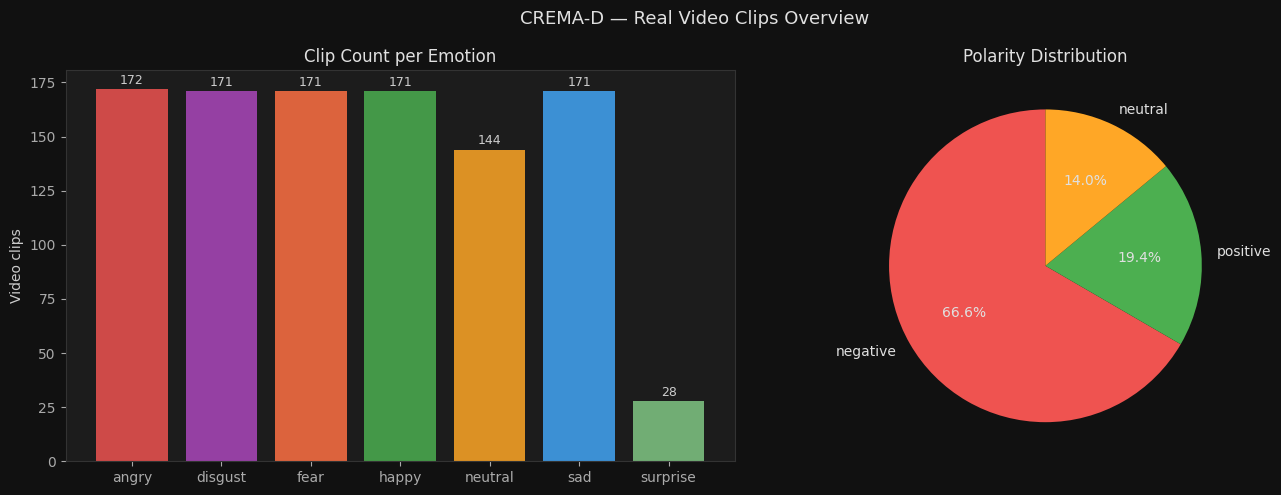

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colours = [EMOTION_COLOURS[e] for e in dist.index]
axes[0].bar(dist.index, dist.values, color=colours, edgecolor="none", alpha=0.85)
axes[0].set_title("Clip Count per Emotion", color="#e0e0e0")
axes[0].set_ylabel("Video clips")
for bar, v in zip(axes[0].patches, dist.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 str(v), ha="center", va="bottom", fontsize=9, color="#cccccc")

pol  = df["label"].map(VIDEO_TO_POLARITY).value_counts()
pcol = {"positive":"#4CAF50","neutral":"#FFA726","negative":"#EF5350"}
axes[1].pie(pol.values, labels=pol.index,
            colors=[pcol[p] for p in pol.index],
            autopct="%1.1f%%", startangle=90, textprops={"color":"#e0e0e0"})
axes[1].set_title("Polarity Distribution", color="#e0e0e0")

plt.suptitle("CREMA-D — Real Video Clips Overview", fontsize=13, color="#e0e0e0")
plt.tight_layout()
plt.savefig("video_eda.png", dpi=130, bbox_inches="tight", facecolor="#111111")
plt.show()

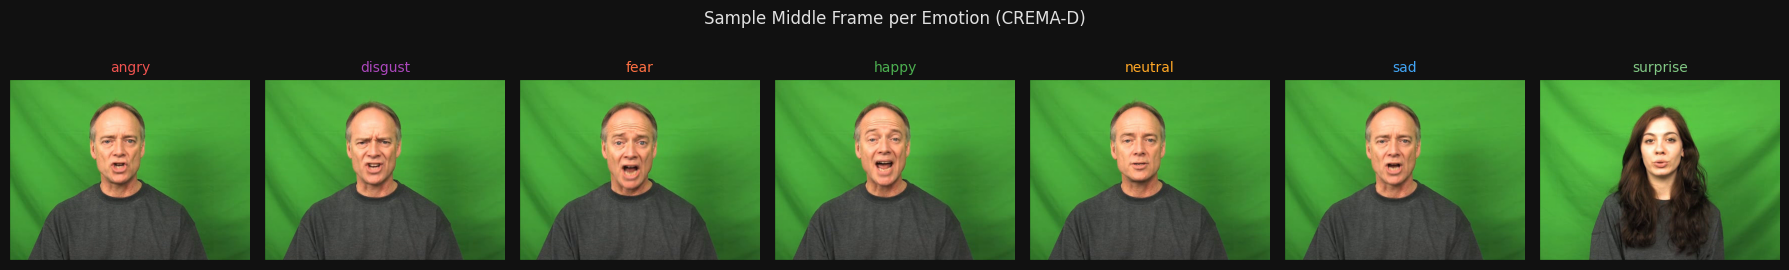

In [6]:
# ── Visualise one middle frame per emotion ───────────────────────────────────
def read_middle_frame(path):
    try:
        cont   = av.open(path)
        frames = [f.to_image().convert("RGB") for f in cont.decode(video=0)]
        cont.close()
        return frames[len(frames)//2] if frames else None
    except Exception:
        return None

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 3))
for ax, emo in zip(axes, EMOTION_CLASSES):
    rows = df[df["label"] == emo]
    frame = None
    for _, row in rows.iterrows():
        frame = read_middle_frame(row["path"])
        if frame: break
    if frame:
        ax.imshow(frame)
    ax.set_title(emo, color=EMOTION_COLOURS[emo], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Middle Frame per Emotion (CREMA-D)", color="#e0e0e0", fontsize=12)
plt.tight_layout()
plt.savefig("video_samples.png", dpi=130, bbox_inches="tight", facecolor="#111111")
plt.show()

## 4 · Video Clip → Tensor (Real PyAV Decoding)

In [7]:
import numpy as np
import torch
import torchvision
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

NumPy: 1.26.4
PyTorch: 2.2.2+cu121
Torchvision: 0.17.2+cu121


In [8]:
import numpy as np
def load_video_clip(video_path, num_frames=NUM_FRAMES,
                    img_size=IMG_SIZE, augment=False):
    """
    Decode a real .flv/.mp4 with PyAV, uniformly sample num_frames frames,
    return float tensor (3, T, H, W).
    """
    try:
        cont       = av.open(video_path)
        all_frames = [f.to_image().convert("RGB") for f in cont.decode(video=0)]
        cont.close()
    except Exception:
        return torch.zeros(3, num_frames, img_size, img_size)

    n = len(all_frames)
    if n == 0:
        return torch.zeros(3, num_frames, img_size, img_size)

    idx    = np.linspace(0, n-1, num_frames, dtype=int)
    frames = [all_frames[i] for i in idx]

    aug = ([T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            T.RandomResizedCrop(img_size, scale=(0.85, 1.0))]
           if augment else [])

    tfm = T.Compose(aug + [
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

    return torch.stack([tfm(f) for f in frames], dim=1)   # (3, T, H, W)


# ── Sanity check ──────────────────────────────────────────────────────────────
t0   = time.time()
clip = load_video_clip(df["path"].iloc[0])
print(f"Shape      : {tuple(clip.shape)}")
print(f"dtype      : {clip.dtype}")
print(f"Min/Max    : {clip.min():.3f} / {clip.max():.3f}")
print(f"Decode time: {time.time()-t0:.2f}s")

Shape      : (3, 16, 112, 112)
dtype      : torch.float32
Min/Max    : -1.686 / 2.249
Decode time: 0.19s


## 5 · Stratified Split + Label Encoder

In [9]:
le = LabelEncoder()
le.fit(EMOTION_CLASSES)
df["label_id"] = le.transform(df["label"])

train_df, tmp_df = train_test_split(df, test_size=0.30,
                                    stratify=df["label_id"], random_state=SEED)
val_df, test_df  = train_test_split(tmp_df, test_size=0.50,
                                    stratify=tmp_df["label_id"], random_state=SEED)

print(f"Train : {len(train_df)}  Val : {len(val_df)}  Test : {len(test_df)}")
print(f"Classes: {list(le.classes_)}")

with open(SAVE_DIR/"label_encoder.pkl","wb") as f:
    pickle.dump(le, f)
print(f"Label encoder → {SAVE_DIR/'label_encoder.pkl'}")

Train : 719  Val : 154  Test : 155
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Label encoder → saved_models/video_emotion/label_encoder.pkl


## 6 · PyTorch Dataset & DataLoaders

In [10]:
class VideoEmotionDataset(Dataset):
    """Streams real .flv clips on-the-fly via PyAV."""
    def __init__(self, dataframe, augment=False):
        self.df      = dataframe.reset_index(drop=True)
        self.augment = augment
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return load_video_clip(row["path"], augment=self.augment), int(row["label_id"])

train_ds = VideoEmotionDataset(train_df, augment=True)
val_ds   = VideoEmotionDataset(val_df)
test_ds  = VideoEmotionDataset(test_df)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train/Val/Test batches: {len(train_loader)} / {len(val_loader)} / {len(test_loader)}")
clips, labels = next(iter(train_loader))
print(f"Batch shape: {tuple(clips.shape)}  labels: {labels.tolist()}")

Train/Val/Test batches: 90 / 20 / 20
Batch shape: (8, 3, 16, 112, 112)  labels: [4, 1, 1, 6, 2, 2, 0, 5]


## 7 · Model — R3D-18 + Temporal Attention Pool

In [11]:
class TemporalAttentionPool(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.attn = nn.Linear(in_dim, 1)
    def forward(self, x):
        # x: (B, C, T, 1, 1)
        B, C, T, _, _ = x.shape
        x = x.squeeze(-1).squeeze(-1).permute(0, 2, 1)   # (B, T, C)
        w = torch.softmax(self.attn(x), dim=1)            # (B, T, 1)
        return (x * w).sum(dim=1)                         # (B, C)

class VideoEmotionModel(nn.Module):
    """R3D-18 backbone + temporal attention + 7-class head."""
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        base           = video_models.r3d_18(weights="DEFAULT")
        self.backbone  = nn.Sequential(*list(base.children())[:-2])
        self.sp_pool   = nn.AdaptiveAvgPool3d((None, 1, 1))
        self.temp_attn = TemporalAttentionPool(512)
        self.head      = nn.Sequential(
            nn.LayerNorm(512), nn.Linear(512, 256), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(256, num_classes),
        )
    def forward(self, x):
        f = self.sp_pool(self.backbone(x))  # (B, 512, T', 1, 1)
        return self.head(self.temp_attn(f))  # (B, 7)

model     = VideoEmotionModel(NUM_CLASSES).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
dummy = torch.randn(2, 3, NUM_FRAMES, IMG_SIZE, IMG_SIZE).to(DEVICE)
print(f"Output shape    : {tuple(model(dummy).shape)}  ← (batch=2, classes=7)")

Total params    : 33,300,936
Trainable params: 33,300,936
Output shape    : (2, 7)  ← (batch=2, classes=7)


## 8 · Training (Discriminative LRs + Label Smoothing + Early Stop)

In [12]:
optimizer = optim.Adam([
    {"params": model.backbone.parameters(),  "lr": LR/10},
    {"params": model.temp_attn.parameters(), "lr": LR},
    {"params": model.head.parameters(),      "lr": LR},
], weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history      = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[],"lr":[]}
best_val_acc = 0.0
patience     = 8
no_improve   = 0
best_ckpt    = SAVE_DIR/"best_video_model.pt"

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for clips, labels in tqdm(loader, leave=False, desc="Train" if train else "Val  "):
            clips, labels = clips.to(DEVICE), labels.to(DEVICE)
            logits = model(clips)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
            total_loss += loss.item()*len(labels)
            correct    += (logits.argmax(1)==labels).sum().item()
            total      += len(labels)
    return total_loss/total, correct/total

print(f"Training up to {EPOCHS} epochs  patience={patience}  device={DEVICE}\n")
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader,   train=False)
    scheduler.step()
    lr = scheduler.get_last_lr()[0]
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)
    history["lr"].append(lr)

    flag = ""
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), best_ckpt)
        no_improve = 0; flag = "  ← best"
    else:
        no_improve += 1
    print(f"Ep {epoch:02d}/{EPOCHS}  "
          f"trn_loss={tl:.4f} trn_acc={ta*100:.1f}%  "
          f"val_loss={vl:.4f} val_acc={va*100:.1f}%  "
          f"lr={lr:.2e}  [{time.time()-t0:.0f}s]{flag}")
    if no_improve >= patience:
        print(f"\nEarly stop at epoch {epoch}."); break

print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")

Training up to 40 epochs  patience=8  device=cuda



Train:   0%|          | 0/90 [00:00<?, ?it/s]

Val  :   0%|          | 0/20 [00:00<?, ?it/s]

Ep 01/40  trn_loss=1.9592 trn_acc=24.1%  val_loss=1.7020 val_acc=33.8%  lr=9.98e-05  [289s]  ← best


Train:   0%|          | 0/90 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/20 [00:00<?, ?it/s]

Ep 39/40  trn_loss=0.5302 trn_acc=96.1%  val_loss=1.0059 val_acc=77.3%  lr=1.15e-06  [287s]


Train:   0%|          | 0/90 [00:00<?, ?it/s]

Val  :   0%|          | 0/20 [00:00<?, ?it/s]

Ep 40/40  trn_loss=0.5241 trn_acc=96.4%  val_loss=1.0025 val_acc=77.3%  lr=1.00e-06  [288s]

Best Val Accuracy: 80.52%


## 9 · Training Curves

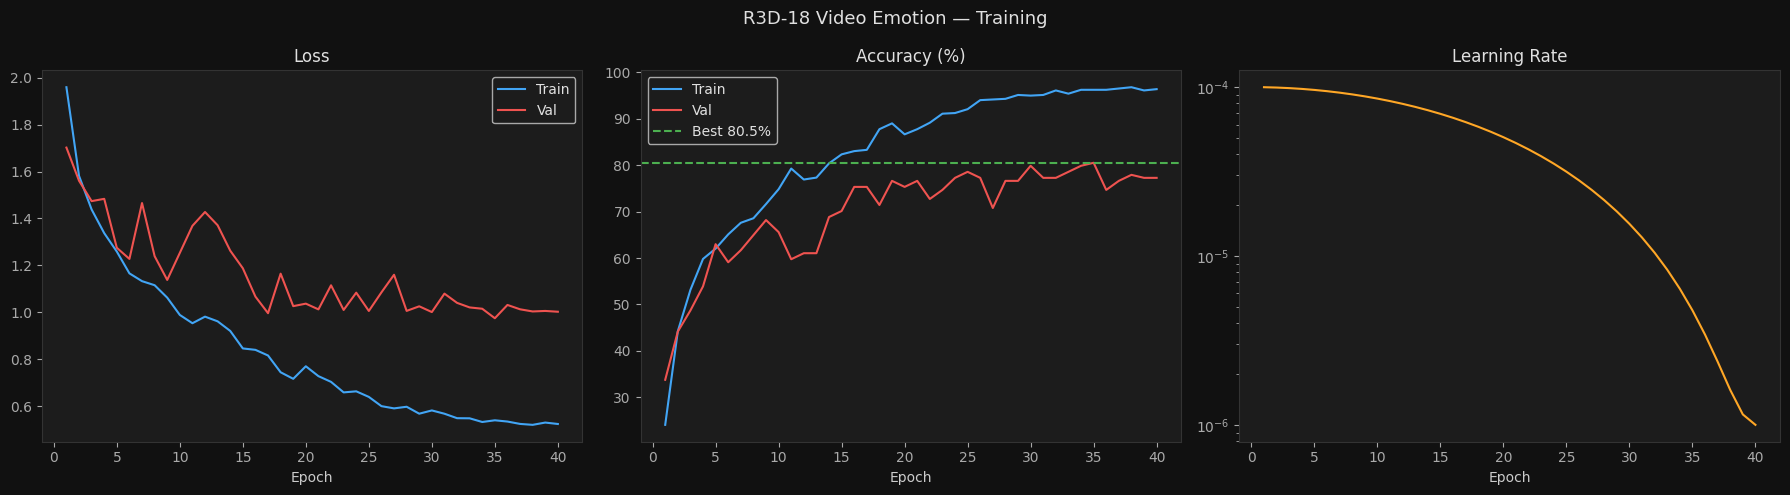

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, len(history["train_loss"])+1)
axes[0].plot(ep, history["train_loss"], label="Train", color="#42A5F5")
axes[0].plot(ep, history["val_loss"],   label="Val",   color="#EF5350")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(ep, [a*100 for a in history["train_acc"]], label="Train", color="#42A5F5")
axes[1].plot(ep, [a*100 for a in history["val_acc"]],   label="Val",   color="#EF5350")
axes[1].axhline(best_val_acc*100, color="#4CAF50", linestyle="--",
               label=f"Best {best_val_acc*100:.1f}%")
axes[1].set_title("Accuracy (%)"); axes[1].legend()

axes[2].plot(ep, history["lr"], color="#FFA726")
axes[2].set_title("Learning Rate"); axes[2].set_yscale("log")
for ax in axes: ax.set_xlabel("Epoch")

plt.suptitle("R3D-18 Video Emotion — Training", fontsize=13, color="#e0e0e0")
plt.tight_layout()
plt.savefig("video_training_curves.png", dpi=130, bbox_inches="tight", facecolor="#111111")
plt.show()

## 10 · Test Evaluation

In [14]:
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for clips, labels in tqdm(test_loader, desc="Testing"):
        all_preds.extend(model(clips.to(DEVICE)).argmax(1).cpu().tolist())
        all_true.extend(labels.tolist())

test_acc = sum(p==t for p,t in zip(all_preds, all_true)) / len(all_true)
print(f"Test Accuracy : {test_acc*100:.2f}%\n")
print(classification_report(all_true, all_preds, target_names=le.classes_, zero_division=0))


Testing:   0%|          | 0/20 [00:00<?, ?it/s]

Test Accuracy : 72.26%

              precision    recall  f1-score   support

       angry       0.78      0.81      0.79        26
     disgust       0.83      0.96      0.89        26
        fear       0.63      0.65      0.64        26
       happy       0.92      0.88      0.90        26
     neutral       0.72      0.62      0.67        21
         sad       0.48      0.50      0.49        26
    surprise       0.00      0.00      0.00         4

    accuracy                           0.72       155
   macro avg       0.62      0.63      0.63       155
weighted avg       0.71      0.72      0.71       155



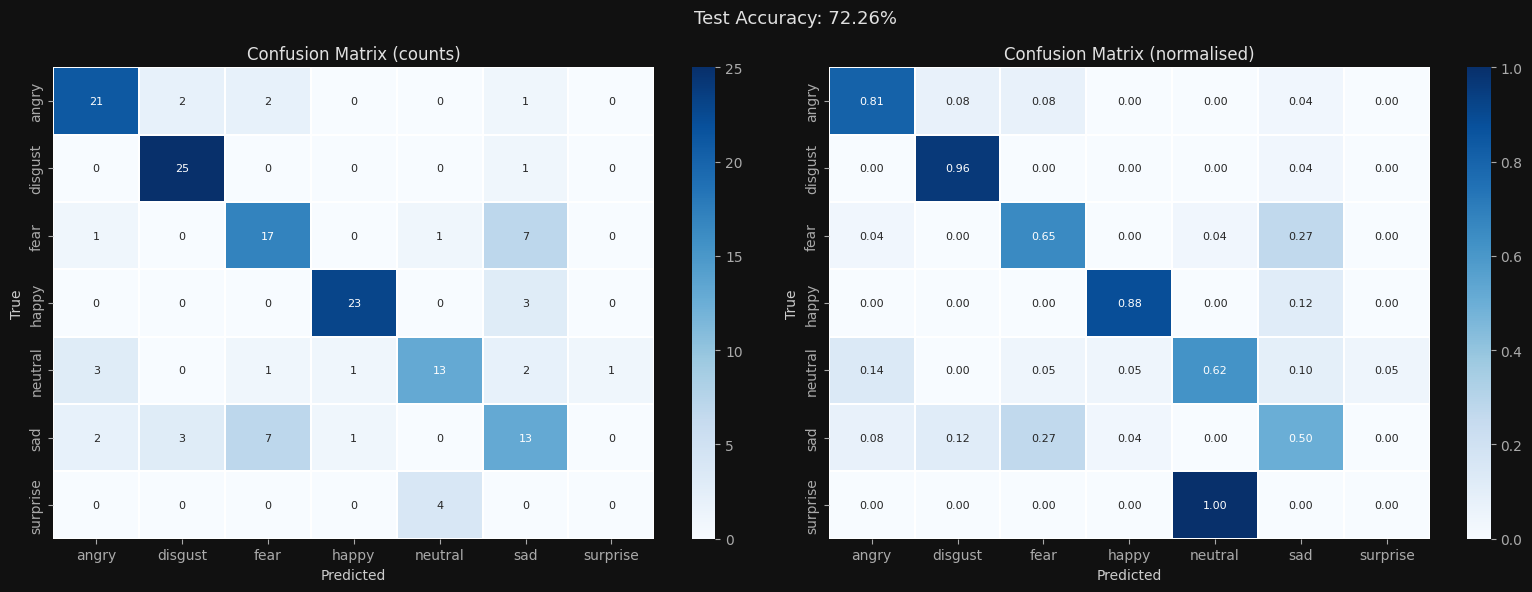

In [15]:
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, fmt in zip(
    axes, [cm, cm_norm],
    ["Confusion Matrix (counts)", "Confusion Matrix (normalised)"],
    ["d", ".2f"]
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
                annot_kws={"size":8}, linewidths=0.3)
    ax.set_title(title, color="#e0e0e0")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle(f"Test Accuracy: {test_acc*100:.2f}%", fontsize=13, color="#e0e0e0")
plt.tight_layout()
plt.savefig("video_confusion_matrix.png", dpi=130, bbox_inches="tight", facecolor="#111111")
plt.show()


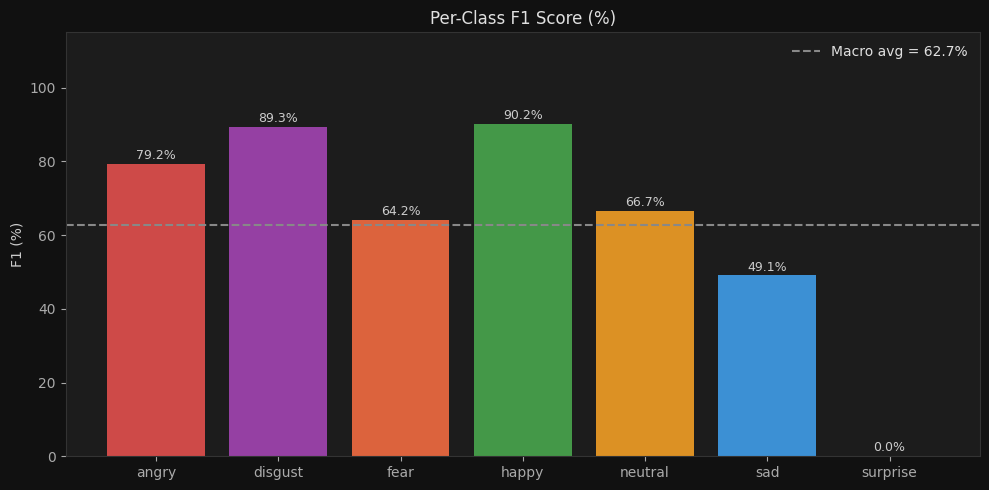

In [16]:
f1_scores = f1_score(all_true, all_preds, average=None, zero_division=0)
fig, ax   = plt.subplots(figsize=(10, 5))
colours   = [EMOTION_COLOURS[c] for c in le.classes_]
bars      = ax.bar(le.classes_, f1_scores*100, color=colours, alpha=0.85, edgecolor="none")
ax.axhline(np.mean(f1_scores)*100, color="#888", linestyle="--",
           label=f"Macro avg = {np.mean(f1_scores)*100:.1f}%")
for bar, v in zip(bars, f1_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9, color="#cccccc")
ax.set_title("Per-Class F1 Score (%)", color="#e0e0e0")
ax.set_ylabel("F1 (%)"); ax.set_ylim(0, 115); ax.legend(framealpha=0)
plt.tight_layout()
plt.savefig("video_f1_scores.png", dpi=130, bbox_inches="tight", facecolor="#111111")
plt.show()

## 11 · `predict_video()` — Primary Inference Function

In [17]:
def predict_video(video_path):
    """
    7-class emotion prediction on a real video file.
    Returns dict with all 7 probabilities as primary output.
    """
    clip = load_video_clip(video_path, augment=False).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(clip), dim=1).squeeze().cpu().numpy()
    top_id  = int(probs.argmax())
    emotion = le.classes_[top_id]
    return {
        "emotion"   : emotion,
        "emotion_id": top_id,
        "confidence": round(float(probs[top_id]), 4),
        "polarity"  : VIDEO_TO_POLARITY[emotion],
        "probs"     : {le.classes_[i]: round(float(probs[i]), 4)
                       for i in range(NUM_CLASSES)},   # PRIMARY OUTPUT
    }

# Test
result = predict_video(df["path"].iloc[0])
print(f"Emotion  : {result['emotion'].upper()} ({result['confidence']*100:.1f}%)")
print(f"Polarity : {result['polarity']}")
print(f"All 7    : {result['probs']}")


Emotion  : ANGRY (75.7%)
Polarity : negative
All 7    : {'angry': 0.757, 'disgust': 0.0278, 'fear': 0.1349, 'happy': 0.0097, 'neutral': 0.0238, 'sad': 0.0307, 'surprise': 0.0161}


## 12 · Demo — One Real Clip per Emotion

Demo — one real RAVDESS clip per emotion:

  Ground truth : ANGRY
  Predicted    : ANGRY  (75.7%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  angry     :  75.70%  ██████████████████████ ← top
  fear      :  13.49%  ████
  sad       :   3.07%  
  disgust   :   2.78%  
  neutral   :   2.38%  
  surprise  :   1.61%  
  happy     :   0.97%  
  ----------------------------------------
  Sum: 1.0000


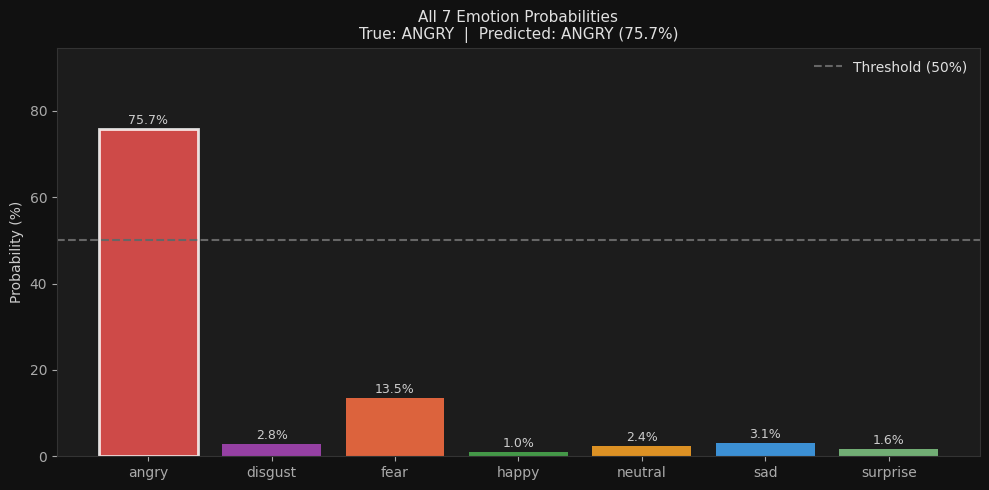


  Ground truth : DISGUST
  Predicted    : DISGUST  (90.3%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  disgust   :  90.35%  ███████████████████████████ ← top
  sad       :   1.76%  
  surprise  :   1.69%  
  angry     :   1.57%  
  fear      :   1.56%  
  neutral   :   1.55%  
  happy     :   1.52%  
  ----------------------------------------
  Sum: 1.0000


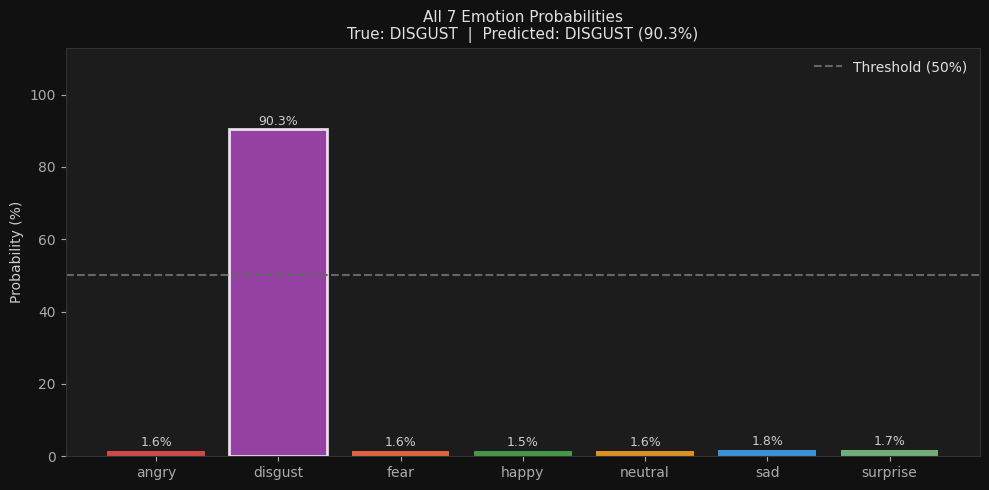


  Ground truth : FEAR
  Predicted    : FEAR  (73.2%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  fear      :  73.25%  █████████████████████ ← top
  disgust   :   8.25%  ██
  happy     :   5.48%  █
  angry     :   3.58%  █
  neutral   :   3.41%  █
  surprise  :   3.30%  
  sad       :   2.74%  
  ----------------------------------------
  Sum: 1.0001


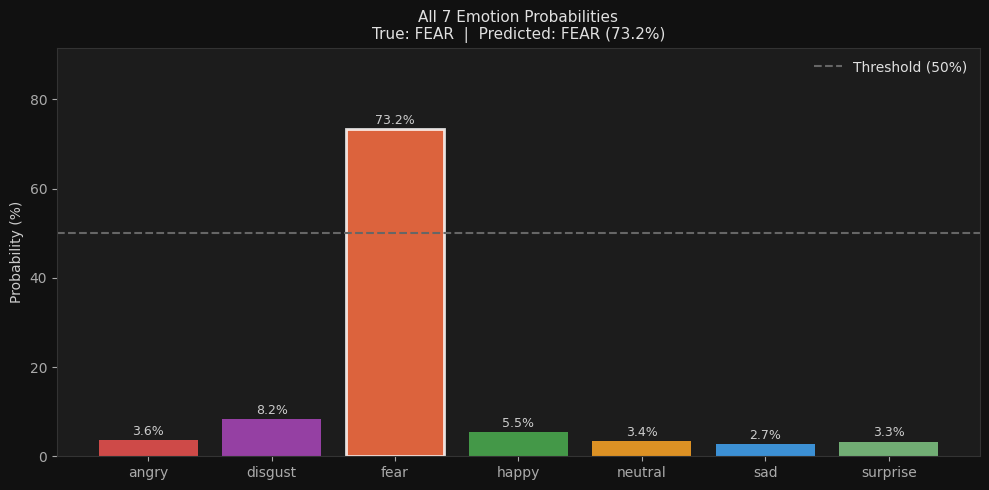


  Ground truth : HAPPY
  Predicted    : HAPPY  (90.3%)
  Polarity     : positive

  All 7 Emotion Probabilities:
  ----------------------------------------
  happy     :  90.31%  ███████████████████████████ ← top
  fear      :   1.76%  
  disgust   :   1.65%  
  angry     :   1.64%  
  surprise  :   1.64%  
  sad       :   1.50%  
  neutral   :   1.49%  
  ----------------------------------------
  Sum: 0.9999


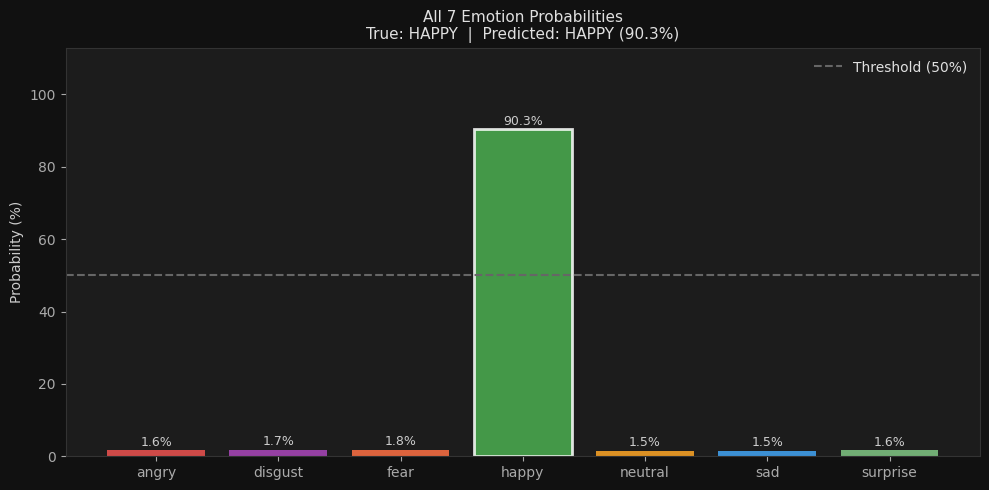


  Ground truth : NEUTRAL
  Predicted    : NEUTRAL  (55.0%)
  Polarity     : neutral

  All 7 Emotion Probabilities:
  ----------------------------------------
  neutral   :  55.01%  ████████████████ ← top
  surprise  :  38.97%  ███████████
  disgust   :   1.55%  
  angry     :   1.48%  
  happy     :   1.07%  
  sad       :   0.98%  
  fear      :   0.94%  
  ----------------------------------------
  Sum: 1.0000


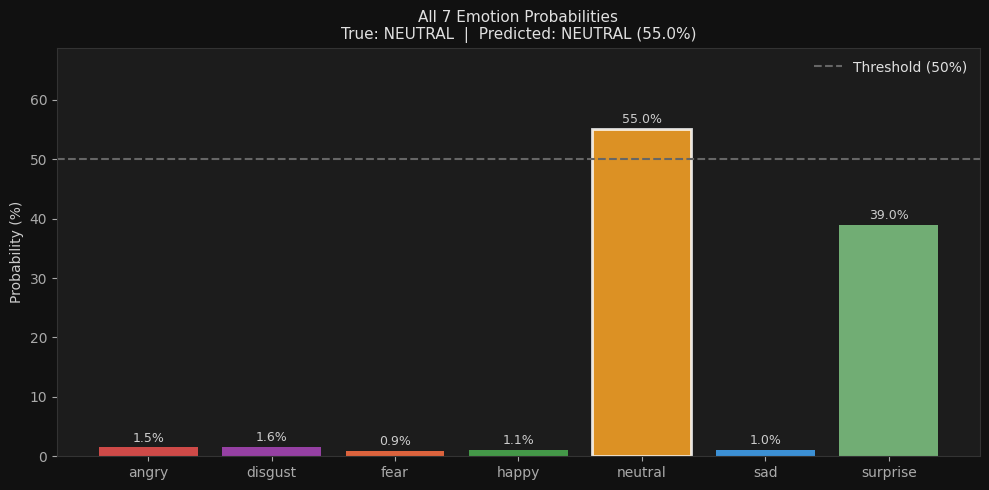


  Ground truth : SAD
  Predicted    : SAD  (68.2%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  sad       :  68.23%  ████████████████████ ← top
  disgust   :  17.67%  █████
  angry     :   4.82%  █
  neutral   :   2.99%  
  fear      :   2.61%  
  surprise  :   2.26%  
  happy     :   1.42%  
  ----------------------------------------
  Sum: 1.0000


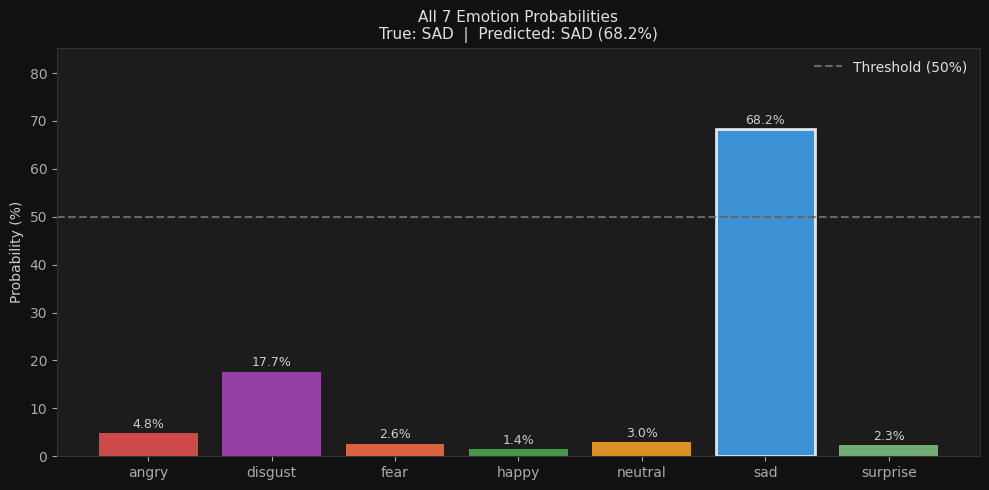


  Ground truth : SURPRISE
  Predicted    : SURPRISE  (52.4%)
  Polarity     : positive

  All 7 Emotion Probabilities:
  ----------------------------------------
  surprise  :  52.43%  ███████████████ ← top
  neutral   :  40.05%  ████████████
  happy     :   2.00%  
  disgust   :   1.71%  
  angry     :   1.48%  
  fear      :   1.24%  
  sad       :   1.09%  
  ----------------------------------------
  Sum: 1.0000


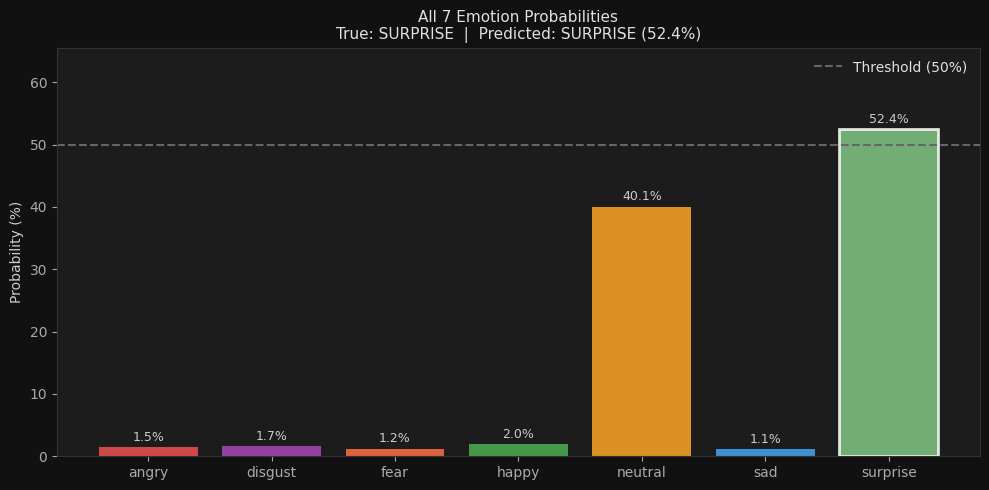

In [18]:
def demo_predict_video(video_path, label="unknown"):
    result = predict_video(video_path)
    print("=" * 55)
    print(f"  Ground truth : {label.upper()}")
    print(f"  Predicted    : {result['emotion'].upper()}  ({result['confidence']*100:.1f}%)")
    print(f"  Polarity     : {result['polarity']}")
    print()
    print("  All 7 Emotion Probabilities:")
    print("  " + "-" * 40)
    for emo, prob in sorted(result["probs"].items(), key=lambda x: -x[1]):
        bar    = "█" * int(prob * 30)
        marker = " ← top" if emo == result["emotion"] else ""
        print(f"  {emo:10s}: {prob*100:6.2f}%  {bar}{marker}")
    print("  " + "-" * 40)
    print(f"  Sum: {sum(result['probs'].values()):.4f}")
    print("=" * 55)

    fig, ax = plt.subplots(figsize=(10, 5))
    emos    = list(result["probs"].keys())
    vals    = [result["probs"][e]*100 for e in emos]
    colours = [EMOTION_COLOURS[e] for e in emos]
    bars    = ax.bar(emos, vals, color=colours, alpha=0.85, edgecolor="none")
    bars[emos.index(result["emotion"])].set_edgecolor("white")
    bars[emos.index(result["emotion"])].set_linewidth(2)
    ax.axhline(CONF_THRESHOLD*100, color="#666", linestyle="--",
               label=f"Threshold ({CONF_THRESHOLD:.0%})")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color="#cccccc")
    ax.set_title(
        f"All 7 Emotion Probabilities\n"
        f"True: {label.upper()}  |  Predicted: {result['emotion'].upper()} "
        f"({result['confidence']*100:.1f}%)",
        fontsize=11, color="#e0e0e0")
    ax.set_ylabel("Probability (%)"); ax.set_ylim(0, max(vals)*1.25)
    ax.legend(framealpha=0); plt.tight_layout()
    plt.savefig(f"video_demo_{label}.png", dpi=130,
                bbox_inches="tight", facecolor="#111111")
    plt.show()
    return result

print("Demo — one real RAVDESS clip per emotion:\n")
for emo in EMOTION_CLASSES:
    row = df[df["label"] == emo].iloc[0]
    demo_predict_video(row["path"], label=emo)
    print()


## 13 · Save Model & Metadata

In [19]:
meta = {
    "model_name"     : "VideoEmotionModel_R3D18",
    "backbone"       : "r3d_18 (Kinetics-400 pretrained)",
    "dataset"        : "RAVDESS — real .mp4 video clips",
    "num_classes"    : NUM_CLASSES,
    "emotion_classes": list(le.classes_),
    "polarity_map"   : VIDEO_TO_POLARITY,
    "img_size"       : IMG_SIZE,
    "num_frames"     : NUM_FRAMES,
    "best_val_acc"   : round(best_val_acc, 4),
    "test_acc"       : round(test_acc, 4),
    "conf_threshold" : CONF_THRESHOLD,
    "checkpoint"     : str(best_ckpt),
    "label_encoder"  : str(SAVE_DIR/"label_encoder.pkl"),
}
meta_path = SAVE_DIR/"video_model_meta.json"
with open(meta_path,"w") as f:
    json.dump(meta, f, indent=2)

print("=" * 55)
print("Saved:")
print(f"  Model   : {best_ckpt}")
print(f"  Encoder : {SAVE_DIR/'label_encoder.pkl'}")
print(f"  Meta    : {meta_path}")
print("=" * 55)
for k, v in meta.items():
    if k not in ("emotion_classes","polarity_map"):
        print(f"  {k:20s}: {v}")
print("\nNext → 07_fusion_video_audio_text.ipynb")


Saved:
  Model   : saved_models/video_emotion/best_video_model.pt
  Encoder : saved_models/video_emotion/label_encoder.pkl
  Meta    : saved_models/video_emotion/video_model_meta.json
  model_name          : VideoEmotionModel_R3D18
  backbone            : r3d_18 (Kinetics-400 pretrained)
  dataset             : RAVDESS — real .mp4 video clips
  num_classes         : 7
  img_size            : 112
  num_frames          : 16
  best_val_acc        : 0.8052
  test_acc            : 0.7226
  conf_threshold      : 0.5
  checkpoint          : saved_models/video_emotion/best_video_model.pt
  label_encoder       : saved_models/video_emotion/label_encoder.pkl

Next → 07_fusion_video_audio_text.ipynb


## 14 · Fusion Integration Snippet

In [20]:
# Copy this into your fusion notebook
SNIPPET = '''
import json, pickle, torch
from pathlib import Path

VIDEO_DIR = Path("saved_models/video_emotion")
with open(VIDEO_DIR/"video_model_meta.json") as f:
    video_meta = json.load(f)
with open(VIDEO_DIR/"label_encoder.pkl","rb") as f:
    video_le = pickle.load(f)

video_model = VideoEmotionModel(num_classes=video_meta["num_classes"]).to(DEVICE)
video_model.load_state_dict(torch.load(video_meta["checkpoint"], map_location=DEVICE))
video_model.eval()
print("Video model loaded ✓")

# Predict from any .mp4
result = predict_video("clip.mp4")
# result["probs"]    ← PRIMARY: all 7 emotion probabilities
# result["emotion"]  ← top emotion string
# result["polarity"] ← 'positive' | 'neutral' | 'negative'
'''
print(SNIPPET)



import json, pickle, torch
from pathlib import Path

VIDEO_DIR = Path("saved_models/video_emotion")
with open(VIDEO_DIR/"video_model_meta.json") as f:
    video_meta = json.load(f)
with open(VIDEO_DIR/"label_encoder.pkl","rb") as f:
    video_le = pickle.load(f)

video_model = VideoEmotionModel(num_classes=video_meta["num_classes"]).to(DEVICE)
video_model.load_state_dict(torch.load(video_meta["checkpoint"], map_location=DEVICE))
video_model.eval()
print("Video model loaded ✓")

# Predict from any .mp4
result = predict_video("clip.mp4")
# result["probs"]    ← PRIMARY: all 7 emotion probabilities
# result["emotion"]  ← top emotion string
# result["polarity"] ← 'positive' | 'neutral' | 'negative'

